# 🩺 Pneumonia Detection Using Convolutional Neural Networks (CNN)

## Project Overview

Pneumonia is a serious lung infection that can be diagnosed using chest X-ray images. In this project, we build a Convolutional Neural Network (CNN) that classifies chest X-ray images into two categories:

- Normal
- Pneumonia

## Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Preprocess Images
5. Data Augmentation
6. Build CNN Model
7. Train the Model
8. Evaluate Performance
9. Save the Model
10. Deploy using Streamlit

# Step 1: Import Required Libraries

In this section, we import all the libraries required for:

- Numerical computations
- Image processing
- Deep Learning
- Data visualization
- Model evaluation

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
Available GPUs: []


# Step 2: Load the Dataset

The Chest X-ray dataset is divided into three folders:

- Train
- Validation
- Test

Each folder contains two classes:

- NORMAL
- PNEUMONIA

In [3]:
dataset_path = "../dataset/chest_xray"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

print(train_path)
print(test_path)
print(val_path)

../dataset/chest_xray\train
../dataset/chest_xray\test
../dataset/chest_xray\val


# Step 3: Count Images in Each Class

Understanding the number of images in each class helps us identify whether the dataset is balanced or imbalanced.

An imbalanced dataset can affect model performance and evaluation.

In [4]:
# Count images in each folder

normal_train = len([
    f for f in os.listdir(os.path.join(train_path, "NORMAL"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

pneumonia_train = len([
    f for f in os.listdir(os.path.join(train_path, "PNEUMONIA"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

normal_val = len([
    f for f in os.listdir(os.path.join(val_path, "NORMAL"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

pneumonia_val = len([
    f for f in os.listdir(os.path.join(val_path, "PNEUMONIA"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

normal_test = len([
    f for f in os.listdir(os.path.join(test_path, "NORMAL"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

pneumonia_test = len([
    f for f in os.listdir(os.path.join(test_path, "PNEUMONIA"))
    if f.endswith((".jpeg", ".jpg", ".png"))
])

print("Training Set")
print(f"Normal Images     : {normal_train}")
print(f"Pneumonia Images : {pneumonia_train}")

print("\nValidation Set")
print(f"Normal Images     : {normal_val}")
print(f"Pneumonia Images : {pneumonia_val}")

print("\nTesting Set")
print(f"Normal Images     : {normal_test}")
print(f"Pneumonia Images : {pneumonia_test}")

Training Set
Normal Images     : 1341
Pneumonia Images : 3875

Validation Set
Normal Images     : 8
Pneumonia Images : 8

Testing Set
Normal Images     : 234
Pneumonia Images : 390


# Step 4: Visualize Class Distribution

Visualizing the class distribution helps us identify whether the dataset is balanced or imbalanced.

This is an important step because class imbalance can influence the learning process of a deep learning model.

# Step 5: Display Sample Images

In this step, we visualize one sample image from each class to understand the differences between Normal and Pneumonia chest X-rays.

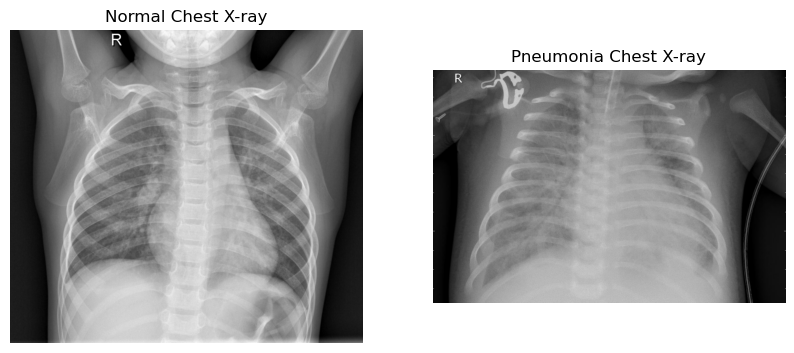

In [5]:
# Display one sample image from each class

normal_files = sorted([
    f for f in os.listdir(os.path.join(train_path, "NORMAL"))
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
])

pneumonia_files = sorted([
    f for f in os.listdir(os.path.join(train_path, "PNEUMONIA"))
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
])

normal_img = cv2.cvtColor(
    cv2.imread(os.path.join(train_path, "NORMAL", normal_files[0])),
    cv2.COLOR_BGR2RGB
)

pneumonia_img = cv2.cvtColor(
    cv2.imread(os.path.join(train_path, "PNEUMONIA", pneumonia_files[0])),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(normal_img)
plt.title("Normal Chest X-ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img)
plt.title("Pneumonia Chest X-ray")
plt.axis("off")

plt.show()

# Step 6: Inspect Image Dimensions

Images in the dataset have different resolutions. However, a CNN requires all input images to have the same dimensions.

In this step, we inspect the shape of sample images before resizing them.

In [6]:
print("Normal Image Shape:", normal_img.shape)
print("Pneumonia Image Shape:", pneumonia_img.shape)

Normal Image Shape: (1858, 2090, 3)
Pneumonia Image Shape: (760, 1152, 3)


# Step 7: Image Preprocessing

Deep learning models cannot directly work with images of different sizes and pixel ranges.

In this step, we will:

- Resize all images to a fixed size (224 × 224)
- Normalize pixel values from 0–255 to 0–1
- Generate images in batches for efficient training

In [7]:
# Image dimensions
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

# Number of images processed in one iteration
BATCH_SIZE = 32

# Step 8: Create Image Data Generators

The `ImageDataGenerator` class loads images from the dataset, resizes them to a fixed size, normalizes the pixel values, and generates batches of images during training.

This makes the training process memory-efficient and prepares the images in a format that can be directly used by the CNN.

In [33]:
# Training Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation Data Generator
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

# Testing Data Generator
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

# Step 9: Create Data Generators

ImageDataGenerator loads images from disk, preprocesses them, and supplies them to the CNN in batches.

In this step, we:
- Resize all images to 224 × 224
- Normalize pixel values to the range [0, 1]
- Generate batches of images for training, validation, and testing

In [34]:
# Training Data
train_generator = train_datagen.flow_from_directory(
    directory=train_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

# Validation Data
validation_generator = val_datagen.flow_from_directory(
    directory=val_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Testing Data
test_generator = test_datagen.flow_from_directory(
    directory=test_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Step 10: Verify the Data Generator

After creating the data generators, we inspect some of their properties to ensure the dataset has been loaded correctly.

In [10]:
print("Class Indices:")
print(train_generator.class_indices)

print("\nNumber of Training Images:", train_generator.samples)
print("Number of Validation Images:", validation_generator.samples)
print("Number of Testing Images:", test_generator.samples)

Class Indices:
{'NORMAL': 0, 'PNEUMONIA': 1}

Number of Training Images: 5216
Number of Validation Images: 16
Number of Testing Images: 624


# Step 11: Build the Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is a deep learning model designed for image classification.

The CNN learns hierarchical features from images:

- Low-level features (edges and corners)
- Mid-level features (textures and shapes)
- High-level features (lung patterns)

The model consists of:

- Convolution Layers
- Pooling Layers
- Flatten Layer
- Fully Connected Layers
- Output Layerm

A Convolutional Neural Network (CNN) is a specialized neural network designed for image data.

Instead of manually extracting features, a CNN automatically learns features such as edges, textures, shapes, and complex patterns directly from images.

We will build the CNN one layer at a time to understand the purpose of each layer.

In [11]:
model = Sequential()

# Step 12: Add the First Convolution Layer

The first convolution layer extracts low-level features from the input images, such as edges, corners, and simple textures.

We use:
- 32 filters
- 3 × 3 kernel
- ReLU activation
- Input image size of 224 × 224 × 3

In [12]:
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    )
)

C:\Users\srika\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 13: Add the Max Pooling Layer

After convolution, the generated feature maps can be large.

Max Pooling reduces their spatial dimensions while preserving the most significant features, making the model more computationally efficient.

In [13]:
model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

# Step 14: Add the Second Convolution Block

The second convolution block learns more complex features by processing the feature maps generated from the first block.

As the network becomes deeper, it gradually learns higher-level visual patterns that are useful for image classification.

In [14]:
# Second Convolution Layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    )
)

# Second Max Pooling Layer
model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

In [15]:
model.add(Flatten())

In [16]:
model.add(
    Dense(
        units=128,
        activation="relu"
    )
)

# Step 15: Add Dropout Layer

Dropout is a regularization technique used to reduce overfitting.

During training, it randomly deactivates a fraction of neurons, forcing the network to learn more robust feature representations instead of relying on a small subset of neurons.

In [17]:
model.add(
    Dropout(0.5)
)

# Step 16: Add the Output Layer

The output layer produces the final prediction.

Since this is a binary classification problem (Normal vs Pneumonia), we use:

- 1 output neuron
- Sigmoid activation function

The sigmoid function outputs a probability between 0 and 1, representing the likelihood that the input image belongs to the Pneumonia class.

In [18]:
model.add(
    Dense(
        units=1,
        activation="sigmoid"
    )
)

# Step 17: Compile the CNN Model

Before training, the model must be compiled.

Compilation defines:

- Optimizer → How the model updates its weights.
- Loss Function → How the model measures its prediction error.
- Metrics → How the model's performance is evaluated during training.

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 18: Train the CNN Model

The `model.fit()` function starts the training process.

During training, the model:

1. Receives a batch of images.
2. Makes predictions.
3. Calculates the loss.
4. Updates its weights using the optimizer.
5. Repeats this process for multiple epochs until it learns meaningful patterns.

In [20]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9057 - loss: 0.3782 - val_accuracy: 0.6250 - val_loss: 0.6714
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 755ms/step - accuracy: 0.9597 - loss: 0.1107 - val_accuracy: 0.9375 - val_loss: 0.2338
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 711ms/step - accuracy: 0.9720 - loss: 0.0801 - val_accuracy: 0.8750 - val_loss: 0.1662
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 698ms/step - accuracy: 0.9751 - loss: 0.0685 - val_accuracy: 0.8125 - val_loss: 0.2969
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 704ms/step - accuracy: 0.9835 - loss: 0.0469 - val_accuracy: 0.8750 - val_loss: 0.5942
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 691ms/step - accuracy: 0.9797 - loss: 0.0528 - val_accuracy: 0.8125 - val_loss: 0.2728
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 688ms/step - accuracy: 0.9889 - loss: 0.0284 - val_accuracy: 1.0000 - val_loss: 0.0388
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 699ms/step - accuracy: 0.9873 - lo

# Step 19: Generate Predictions on the Test Set

Before creating the confusion matrix, we first generate predictions for all images in the test dataset.

The model outputs probabilities between 0 and 1. These probabilities are then converted into binary class labels using a threshold of 0.5.

In [24]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 559ms/step - accuracy: 0.7163 - loss: 2.3329
Test Loss: 2.3329
Test Accuracy: 0.7163


In [25]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype("int32")

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 580ms/step
[[ 60 174]
 [  3 387]]


In [26]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.95      0.26      0.40       234
   PNEUMONIA       0.69      0.99      0.81       390

    accuracy                           0.72       624
   macro avg       0.82      0.62      0.61       624
weighted avg       0.79      0.72      0.66       624



## Model Evaluation

The CNN achieved a test accuracy of **71.63%**.

The model demonstrated an excellent recall of **99%** for the Pneumonia class, successfully identifying almost all pneumonia cases.

However, the recall for the Normal class was only **26%**, indicating that many normal chest X-rays were incorrectly classified as Pneumonia.

This behavior is consistent with the class imbalance present in the training dataset, where pneumonia images significantly outnumber normal images. As a result, the model became biased toward predicting the Pneumonia class.

Future improvements include applying data augmentation, class weighting, and transfer learning to improve the model's generalization performance.

# Step 20: Visualize Training History

Visualizing the training and validation metrics helps us understand how the model learns over time.

We plot:
- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

These plots help identify underfitting, overfitting, and convergence.

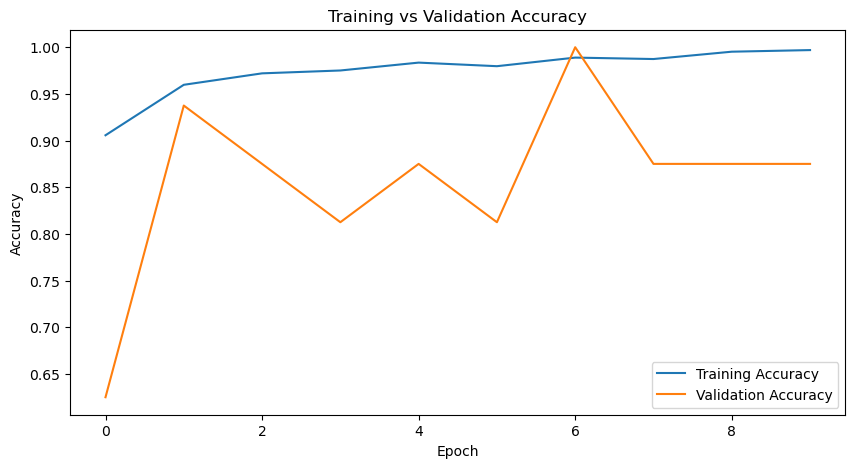

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [28]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


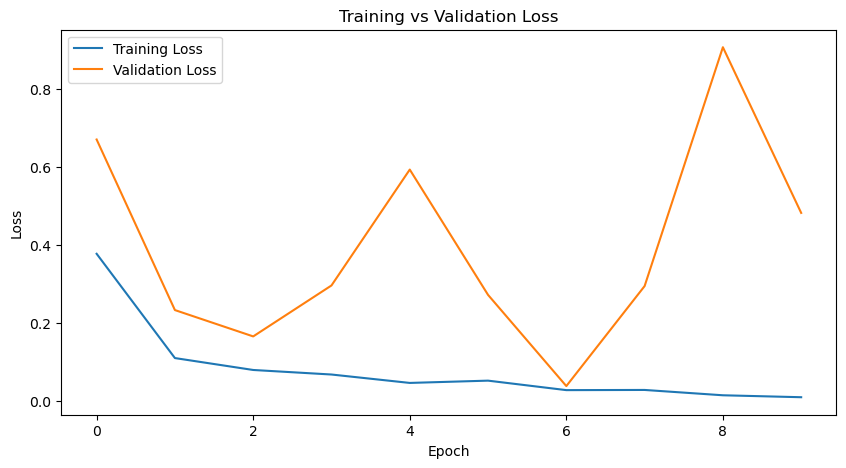

In [29]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [37]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation="sigmoid"))

C:\Users\srika\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.7814 - loss: 0.7928
Epoch 1: val_loss improved from None to 1.09894, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 943ms/step - accuracy: 0.7814 - loss: 0.7928 - val_accuracy: 0.6250 - val_loss: 1.0989
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.8616 - loss: 0.3214
Epoch 2: val_loss improved from 1.09894 to 0.73358, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 875ms/step - accuracy: 0.8616 - loss: 0.3214 - val_accuracy: 0.6875 - val_loss: 0.7336
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.8842 - loss: 0.2732
Epoch 3: val_loss improved from 0.73358 to 0.55764, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 857ms/step - accuracy: 0.8842 - loss: 0.2732 - val_a

In [41]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

In [42]:
test_loss, test_accuracy = best_model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.8734 - loss: 0.3267
Test Loss: 0.3267
Test Accuracy: 0.8734


In [43]:
predictions = best_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step


In [44]:
predicted_classes = (predictions > 0.5).astype("int32")

In [45]:
from sklearn.metrics import confusion_matrix

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[180  54]
 [ 25 365]]


In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.88      0.77      0.82       234
   PNEUMONIA       0.87      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.85      0.86       624
weighted avg       0.87      0.87      0.87       624



# Step 21: Save the Best Model

After training, we save the best-performing model.

Saving the model allows us to reuse it later for prediction and deployment without retraining.

In [47]:
best_model.save("pneumonia_detection_model.keras")